# LSTM Stock Forecast Amazon & Cisco

# Link Video: https://youtu.be/r1BNcuxCO08

Almayra Edgina Rahma 2802460930

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow import keras
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load Data

In [3]:
dfa = pd.read_csv("AMZN.csv")
dfc = pd.read_csv("CSCO.csv")

# Exploratory Data Analysis

## Amazon

In [4]:
dfa

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200
...,...,...,...,...,...,...,...
5753,2020-03-26,1902.000000,1956.489990,1889.290039,1955.489990,1955.489990,6221300
5754,2020-03-27,1930.859985,1939.790039,1899.920044,1900.099976,1900.099976,5387900
5755,2020-03-30,1922.829956,1973.630005,1912.339966,1963.949951,1963.949951,6126100
5756,2020-03-31,1964.349976,1993.020020,1944.010010,1949.719971,1949.719971,5123600


In [5]:
dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5758 entries, 0 to 5757
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5758 non-null   object 
 1   Open       5758 non-null   float64
 2   High       5758 non-null   float64
 3   Low        5758 non-null   float64
 4   Close      5758 non-null   float64
 5   Adj Close  5758 non-null   float64
 6   Volume     5758 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 315.0+ KB


In [6]:
dfa.describe()

,Open,High,Low,Close,Adj Close,Volume
count,5758.000000,5758.000000,5758.000000,5758.000000,5758.000000,5.758000e+03
mean,340.458153,344.156408,336.344390,340.417580,340.417580,7.556094e+06
std,523.365374,528.138556,517.726971,523.140207,523.140207,7.325904e+06
min,1.406250,1.447917,1.312500,1.395833,1.395833,4.872000e+05
25%,37.460001,38.334999,36.812499,37.562500,37.562500,3.685525e+06
50%,81.965000,83.520000,79.875000,81.599998,81.599998,5.692450e+06
75%,335.267494,337.537491,331.727501,334.290001,334.290001,8.594350e+06
max,2173.070068,2185.949951,2161.120117,2170.219971,2170.219971,1.043292e+08


In [7]:
dfa.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [8]:
num = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

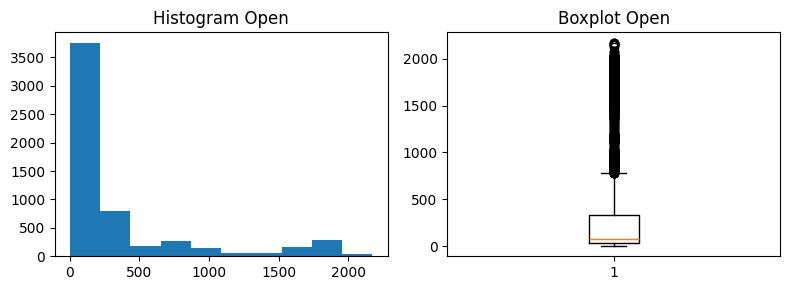

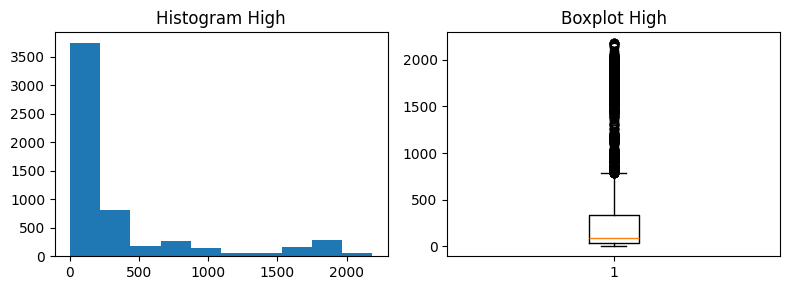

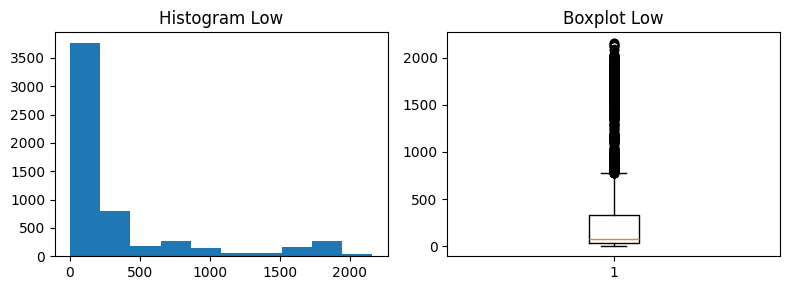

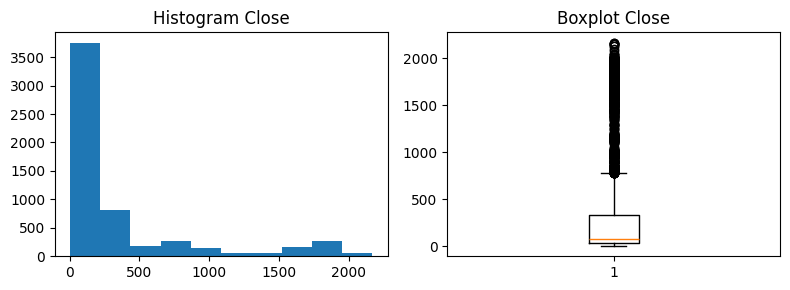

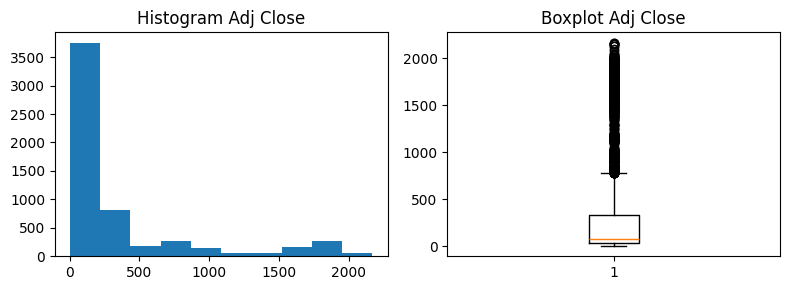

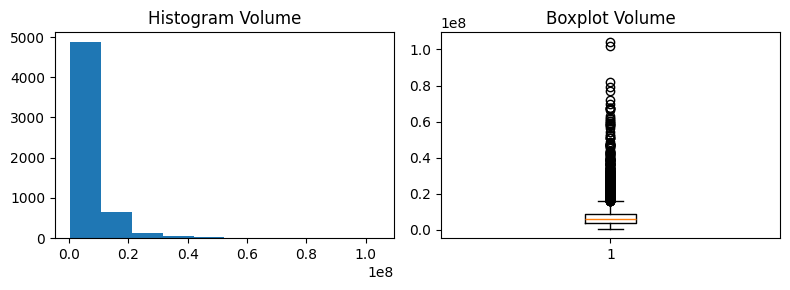

In [9]:
for col in dfa[num].columns:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(dfa[col], bins=10)
    axes[0].set_title(f'Histogram {col}')
    axes[1].boxplot(dfa[col], vert=True)
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

ubah date ke datetime datatype

In [10]:
dfa['Date'] = pd.to_datetime(dfa['Date'])

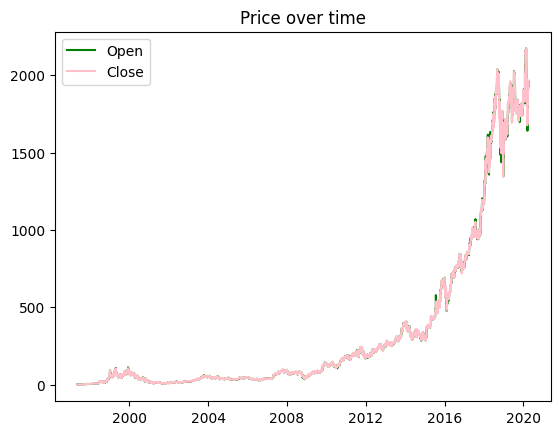

In [11]:
plt.plot(dfa['Date'], dfa['Open'], label="Open",color="green")
plt.plot(dfa['Date'], dfa['Close'], label="Close",color="pink")
plt.title("Price over time")
plt.legend()
plt.show()

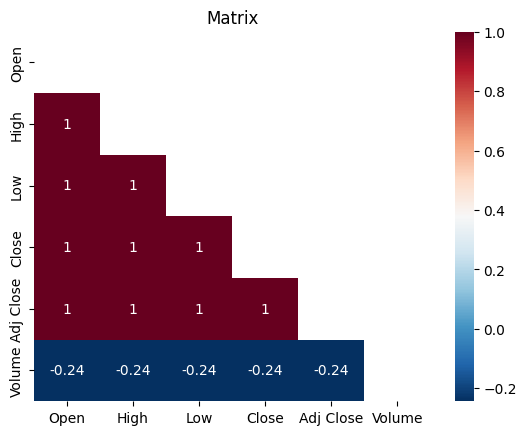

In [12]:
corr = dfa[num].corr()
corrl = corr.loc[corr.index, corr.index]
mask1=np.triu(np.ones_like(corrl, dtype=bool))
sns.heatmap(corr.loc[corr.index, corr.index],cmap='RdBu_r',mask=mask1, annot=True)
plt.title("Matrix")
plt.show()

##Cisco

In [13]:
dfc

,Date,Open,High,Low,Close,Adj Close,Volume
0,1990-02-16,0.000000,0.079861,0.073785,0.077257,0.059806,940636800
1,1990-02-20,0.000000,0.079861,0.074653,0.079861,0.061822,151862400
2,1990-02-21,0.000000,0.078993,0.075521,0.078125,0.060478,70531200
3,1990-02-22,0.000000,0.081597,0.078993,0.078993,0.061150,45216000
4,1990-02-23,0.000000,0.079861,0.078125,0.078559,0.060814,44697600
...,...,...,...,...,...,...,...
7584,2020-03-26,37.970001,40.919998,37.369999,40.580002,40.580002,38473300
7585,2020-03-27,39.209999,40.150002,38.410000,38.820000,38.820000,31278600
7586,2020-03-30,39.450001,40.490002,38.959999,40.320000,40.320000,27120300
7587,2020-03-31,40.130001,40.419998,39.110001,39.310001,39.310001,26014200


In [14]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7589 entries, 0 to 7588
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       7589 non-null   object 
 1   Open       7589 non-null   float64
 2   High       7589 non-null   float64
 3   Low        7589 non-null   float64
 4   Close      7589 non-null   float64
 5   Adj Close  7589 non-null   float64
 6   Volume     7589 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 415.2+ KB


In [15]:
dfc.describe()

,Open,High,Low,Close,Adj Close,Volume
count,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7.589000e+03
mean,20.404527,20.682047,20.116294,20.399541,16.945200,5.680188e+07
std,14.915392,15.133191,14.676149,14.906589,13.253297,4.168727e+07
min,0.000000,0.072917,0.068576,0.071181,0.055102,8.064000e+05
25%,8.444445,8.583333,8.326389,8.479167,6.563846,3.245060e+07
50%,19.700001,19.937500,19.440001,19.680000,15.311988,4.898850e+07
75%,27.129999,27.410000,26.830000,27.120001,21.845076,6.822650e+07
max,81.437500,82.000000,79.062500,80.062500,61.977535,9.406368e+08


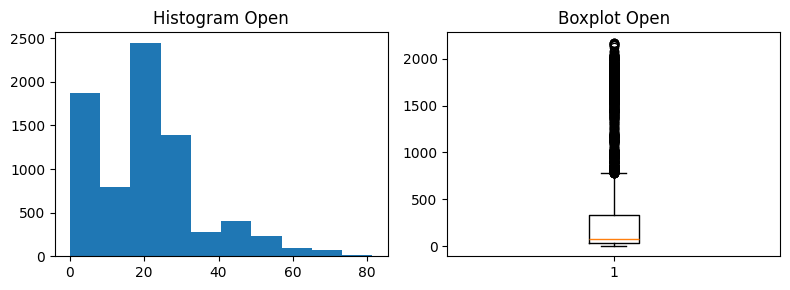

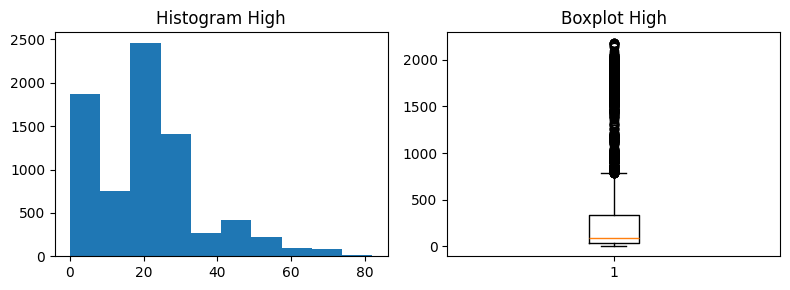

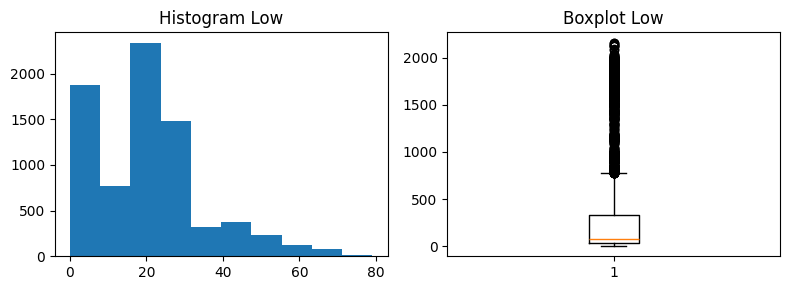

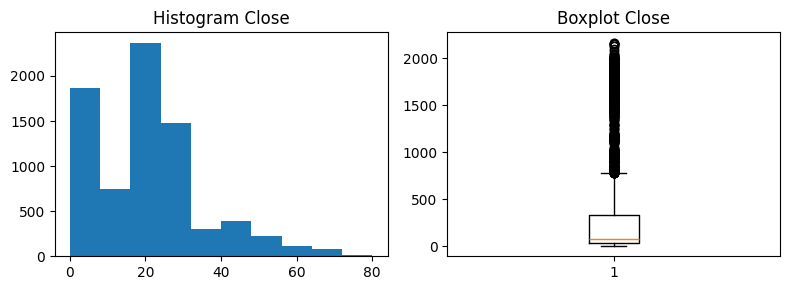

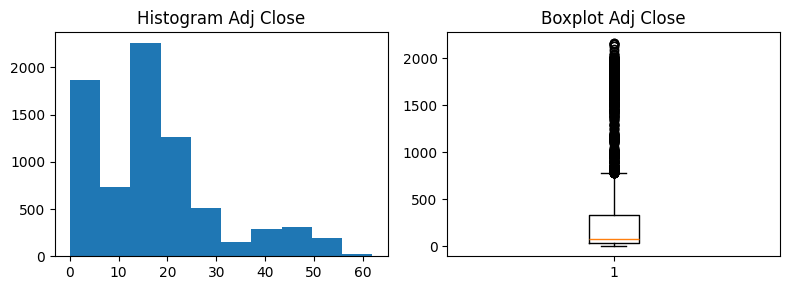

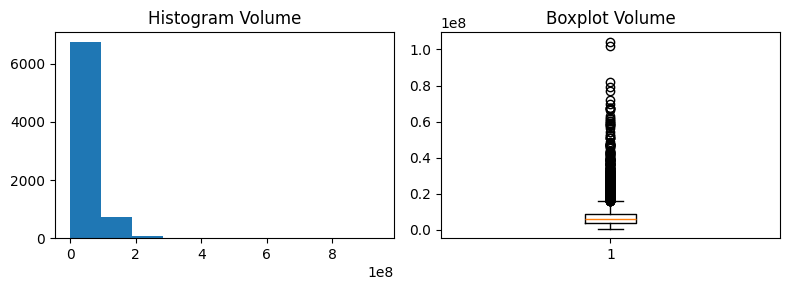

In [16]:
for col in dfc[num].columns:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(dfc[col], bins=10)
    axes[0].set_title(f'Histogram {col}')
    axes[1].boxplot(dfa[col], vert=True)
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

In [17]:
dfc['Date'] = pd.to_datetime(dfc['Date'])

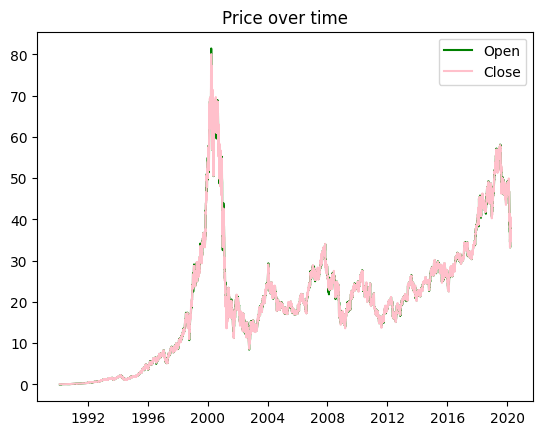

In [18]:
plt.plot(dfc['Date'], dfc['Open'], label="Open",color="green")
plt.plot(dfc['Date'], dfc['Close'], label="Close",color="pink")
plt.title("Price over time")
plt.legend()
plt.show()

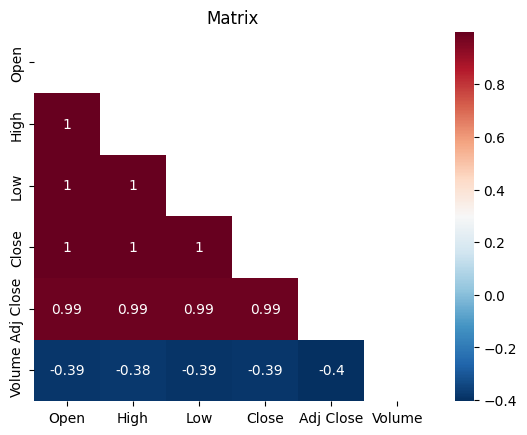

In [19]:
corr = dfc[num].corr()
corrl = corr.loc[corr.index, corr.index]
mask1=np.triu(np.ones_like(corrl, dtype=bool))
sns.heatmap(corr.loc[corr.index, corr.index],cmap='RdBu_r',mask=mask1, annot=True)
plt.title("Matrix")
plt.show()

# Preprocessing

In [20]:
def prepare_data(df, split_date, window=5):
    train = df[df['Date'] < split_date]
    test  = df[df['Date'] >= split_date]

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[['Close']]).flatten()
    X, y = create_dataset(train_scaled,window)

    split = int(len(X)*0.9)

    x_train = X[:split][..., np.newaxis]
    x_val   = X[split:][..., np.newaxis]

    y_train = y[:split]
    y_val   = y[split:]

    full = pd.concat([train[['Close']],test[['Close']]])
    full_scaled = scaler.transform(full[['Close']]).flatten()
    test_series = full_scaled[len(train)-window:]

    x_test, _ = create_dataset(test_series,window)
    x_test = x_test[..., np.newaxis]

    return (train,test,x_train,x_val,y_train,y_val,x_test,scaler)

In [21]:
def create_dataset(series, window=5):
    X, y = [], []

    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])

    return np.array(X), np.array(y)

##Amazon

In [22]:
train,test,x_train, x_val, y_train, y_val, x_test, scaler = prepare_data(dfa,datetime(2019,4,1),window=5)

In [23]:
x_train.shape

(4949, 5, 1)

## Cisco

In [24]:
train2,test2,x_train2, x_val2, y_train2, y_val2, x_test2, scaler2 = prepare_data(dfc,datetime(2019,4,1),window=5)

#Modelling

##Amazon

###Baseline

In [25]:
model = keras.models.Sequential()

model.add(keras.layers.LSTM(50,activation='relu',input_shape=(x_train.shape[1],1)))
model.add(keras.layers.Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer="sgd",loss="mae",metrics=[keras.metrics.RootMeanSquaredError()])

training = model.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=10, batch_size=32)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0469 - root_mean_squared_error: 0.0823 - val_loss: 0.5152 - val_root_mean_squared_error: 0.5383
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0404 - root_mean_squared_error: 0.0705 - val_loss: 0.4703 - val_root_mean_squared_error: 0.4927
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0357 - root_mean_squared_error: 0.0620 - val_loss: 0.4196 - val_root_mean_squared_error: 0.4414
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0305 - root_mean_squared_error: 0.0527 - val_loss: 0.3657 - val_root_mean_squared_error: 0.3866
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0245 - root_mean_squared_error: 0.0423 - val_loss: 0.3042 - val_root_mean_squared_error: 0.3242
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0178 - root_mean_squared_error: 0.0305 - val_loss: 0.2396 - val_root_mean_squared_error: 0.2584
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step 

In [27]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [28]:
y_test = test[['Close']].values

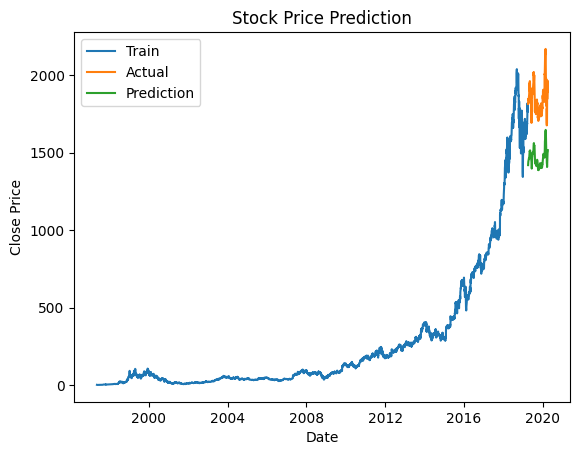

In [29]:
pred_df = pd.DataFrame(predictions,index=test.index,columns=['Predicted'])
plt.plot(train['Date'],train['Close'],label='Train')
plt.plot(test['Date'],test['Close'],label='Actual')
plt.plot(test['Date'],pred_df['Predicted'],label='Prediction')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

### Modified Architecture

In [30]:
modelmod = keras.models.Sequential()

modelmod.add(keras.layers.LSTM(64, return_sequences=False, input_shape=(x_train.shape[1],1)))

modelmod.add(keras.layers.Dense(128, activation="relu"))

modelmod.add(keras.layers.Dropout(0.1))

modelmod.add(keras.layers.Dense(1))

modelmod.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,345 (99.00 KB)

 Trainable params: 25,345 (99.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
modelmod.compile(optimizer="adam",loss="mae",metrics=[keras.metrics.RootMeanSquaredError()])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
trainingmod = modelmod.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=70, batch_size=50,
                           callbacks=early_stop)

Epoch 1/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0097 - root_mean_squared_error: 0.0252 - val_loss: 0.0196 - val_root_mean_squared_error: 0.0238
Epoch 2/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - root_mean_squared_error: 0.0078 - val_loss: 0.0147 - val_root_mean_squared_error: 0.0216
Epoch 3/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0045 - root_mean_squared_error: 0.0076 - val_loss: 0.0132 - val_root_mean_squared_error: 0.0200
Epoch 4/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0040 - root_mean_squared_error: 0.0073 - val_loss: 0.0144 - val_root_mean_squared_error: 0.0194
Epoch 5/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0038 - root_mean_squared_error: 0.0071 - val_loss: 0.0121 - val_root_mean_squared_error: 0.0183
Epoch 6/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0043 - root_mean_squared_error: 0.0076 - val_loss: 0.0121 - val_root_mean_squared_error: 0.0180
Epoch 7/70
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.004

In [32]:
predictionsmod = modelmod.predict(x_test)
predictionsmod = scaler.inverse_transform(predictionsmod)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


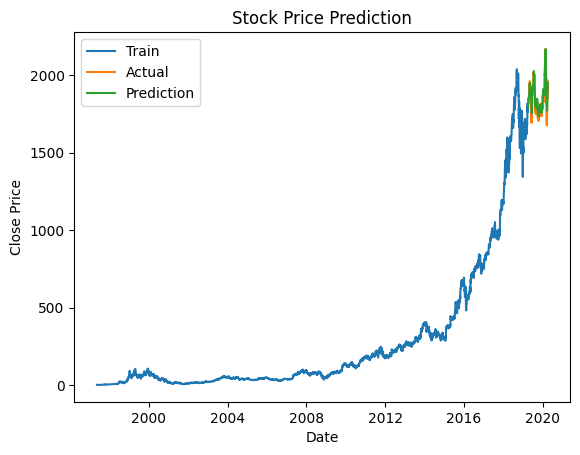

In [33]:
pred_dfmod = pd.DataFrame(predictionsmod,index=test.index,columns=['Predicted'])
plt.plot(train['Date'],train['Close'],label='Train')
plt.plot(test['Date'],test['Close'],label='Actual')
plt.plot(test['Date'],pred_dfmod['Predicted'],label='Prediction')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

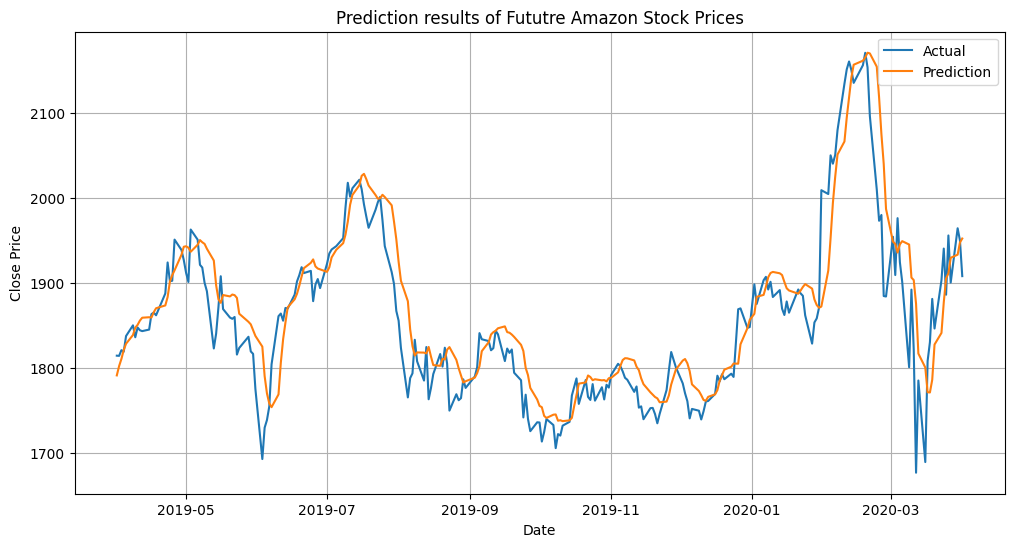

In [34]:
plt.figure(figsize=(12,6))
plt.plot(test['Date'],test['Close'],label='Actual')
plt.plot(test['Date'],pred_dfmod['Predicted'],label='Prediction')

plt.title('Prediction results of Fututre Amazon Stock Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

###Comparison

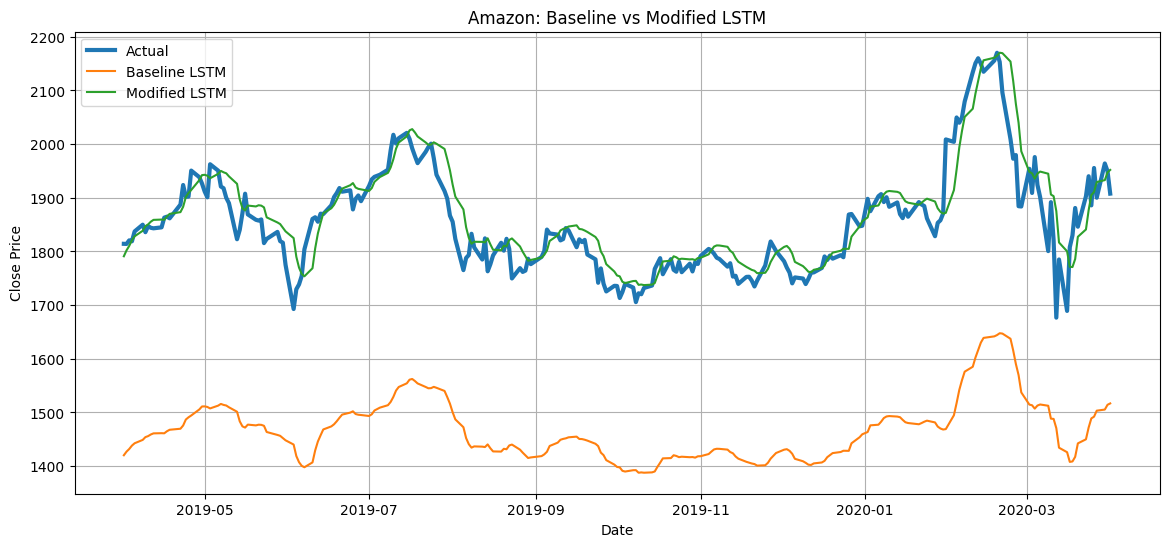

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    test['Date'],
    test['Close'],
    linewidth=3,
    label='Actual'
)

plt.plot(
    test['Date'],
    predictions,
    label='Baseline LSTM'
)

plt.plot(
    test['Date'],
    predictionsmod,
    label='Modified LSTM'
)

plt.title('Amazon: Baseline vs Modified LSTM')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.show()

## Cisco

### Baseline

In [36]:
model2 = keras.models.Sequential()

model2.add(keras.layers.LSTM(50,activation='relu',input_shape=(x_train2.shape[1],1)))
model2.add(keras.layers.Dense(1))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model2.compile(optimizer="sgd",loss="mae",metrics=[keras.metrics.RootMeanSquaredError()])
training2 = model2.fit(x_train2, y_train2, validation_data=(x_val2,y_val2), epochs=10, batch_size=32)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0950 - root_mean_squared_error: 0.1388 - val_loss: 0.1415 - val_root_mean_squared_error: 0.1597
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0572 - root_mean_squared_error: 0.0919 - val_loss: 0.0937 - val_root_mean_squared_error: 0.1097
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0267 - root_mean_squared_error: 0.0563 - val_loss: 0.0299 - val_root_mean_squared_error: 0.0409
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0158 - root_mean_squared_error: 0.0347 - val_loss: 0.0204 - val_root_mean_squared_error: 0.0247
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0138 - root_mean_squared_error: 0.0247 - val_loss: 0.0210 - val_root_mean_squared_error: 0.0227
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0125 - root_mean_squared_error: 0.0186 - val_loss: 0.0143 - val_root_mean_squared_error: 0.0165
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step 

In [38]:
predictions2 = model2.predict(x_test2)
predictions2 = scaler2.inverse_transform(predictions2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [39]:
y_test2 = test2[['Close']].values

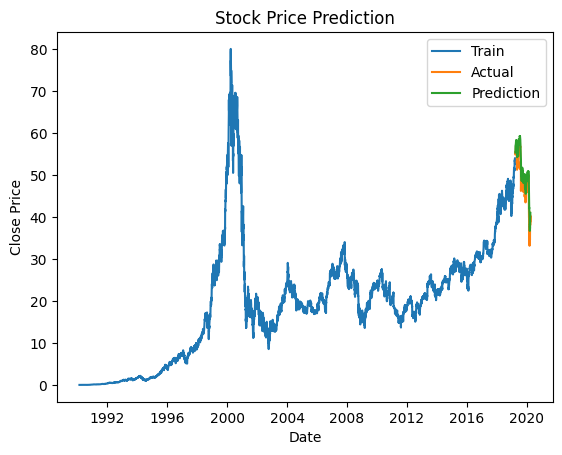

In [40]:
pred_df2 = pd.DataFrame(predictions2,index=test2.index,columns=['Predicted'])
plt.plot(train2['Date'],train2['Close'],label='Train')
plt.plot(test2['Date'],test2['Close'],label='Actual')
plt.plot(test2['Date'],pred_df2['Predicted'],label='Prediction')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

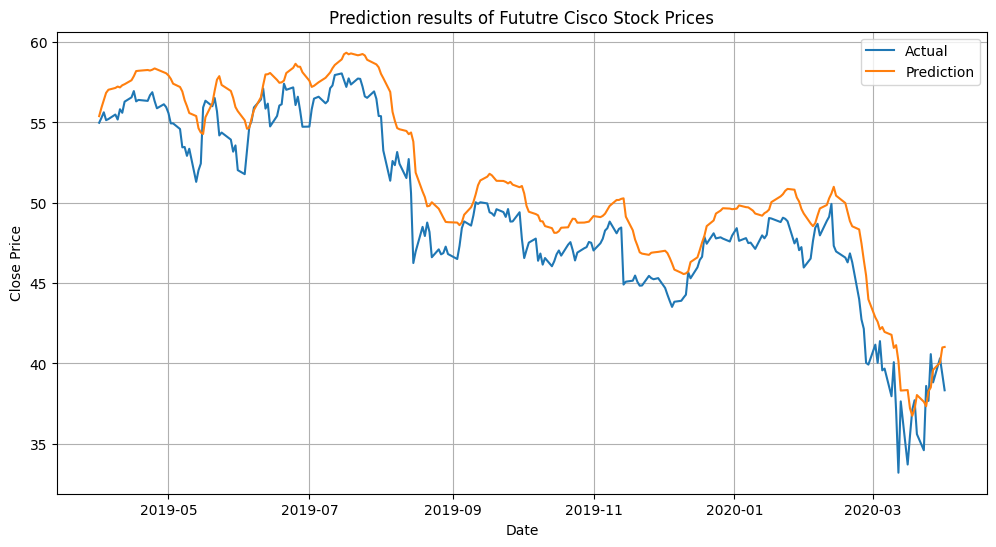

In [41]:
plt.figure(figsize=(12,6))
plt.plot(test2['Date'],test2['Close'],label='Actual')
plt.plot(test2['Date'],pred_df2['Predicted'],label='Prediction')

plt.title('Prediction results of Fututre Cisco Stock Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

###Modified Architecture

In [42]:
modelmod2 = keras.models.Sequential()

modelmod2.add(keras.layers.LSTM(100, return_sequences=False, input_shape=(x_train.shape[1],1)))

modelmod2.add(keras.layers.Dense(32, activation="relu"))

modelmod2.add(keras.layers.Dropout(0.1))

modelmod2.add(keras.layers.Dense(1))

modelmod2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,065 (172.13 KB)

 Trainable params: 44,065 (172.13 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
modelmod2.compile(optimizer="adam",loss="mae",metrics=[keras.metrics.RootMeanSquaredError()])
trainingmod2 = modelmod2.fit(x_train2, y_train2, validation_data=(x_val2,y_val2),
                             callbacks=early_stop,epochs=50, batch_size=32)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0321 - root_mean_squared_error: 0.0633 - val_loss: 0.0367 - val_root_mean_squared_error: 0.0385
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0193 - root_mean_squared_error: 0.0307 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0103
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0172 - root_mean_squared_error: 0.0273 - val_loss: 0.0151 - val_root_mean_squared_error: 0.0169
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0165 - root_mean_squared_error: 0.0255 - val_loss: 0.0061 - val_root_mean_squared_error: 0.0091
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0155 - root_mean_squared_error: 0.0237 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0097
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0150 - root_mean_squared_error: 0.0240 - val_loss: 0.0085 - val_root_mean_squared_error: 0.0107
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

In [44]:
predictionsmod2 = modelmod2.predict(x_test2)
predictionsmod2 = scaler2.inverse_transform(predictionsmod2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


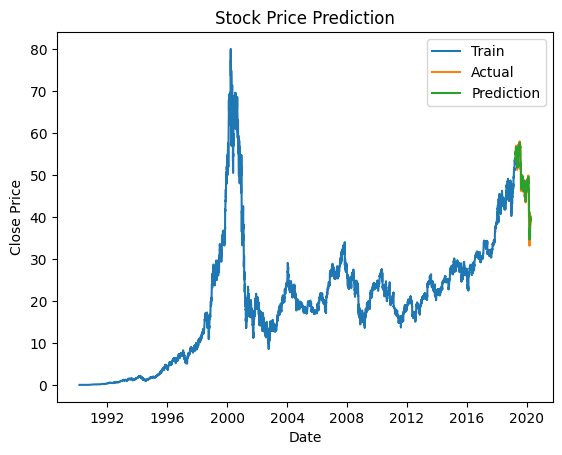

In [45]:
pred_dfmod2 = pd.DataFrame(predictionsmod2,index=test2.index,columns=['Predicted'])
plt.plot(train2['Date'],train2['Close'],label='Train')
plt.plot(test2['Date'],test2['Close'],label='Actual')
plt.plot(test2['Date'],pred_dfmod2['Predicted'],label='Prediction')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

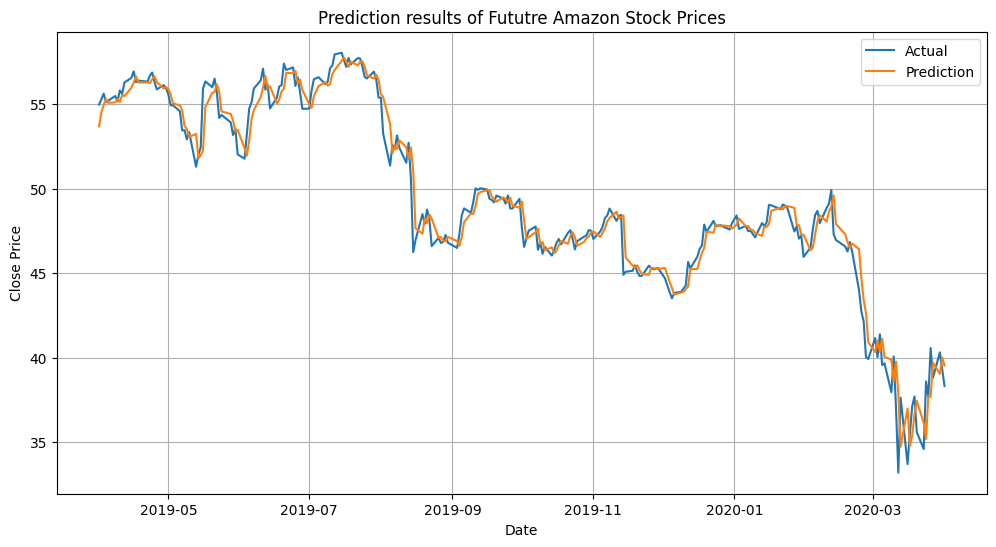

In [46]:
plt.figure(figsize=(12,6))
plt.plot(test2['Date'],test2['Close'],label='Actual')
plt.plot(test2['Date'],pred_dfmod2['Predicted'],label='Prediction')

plt.title('Prediction results of Fututre Amazon Stock Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

###Comparison

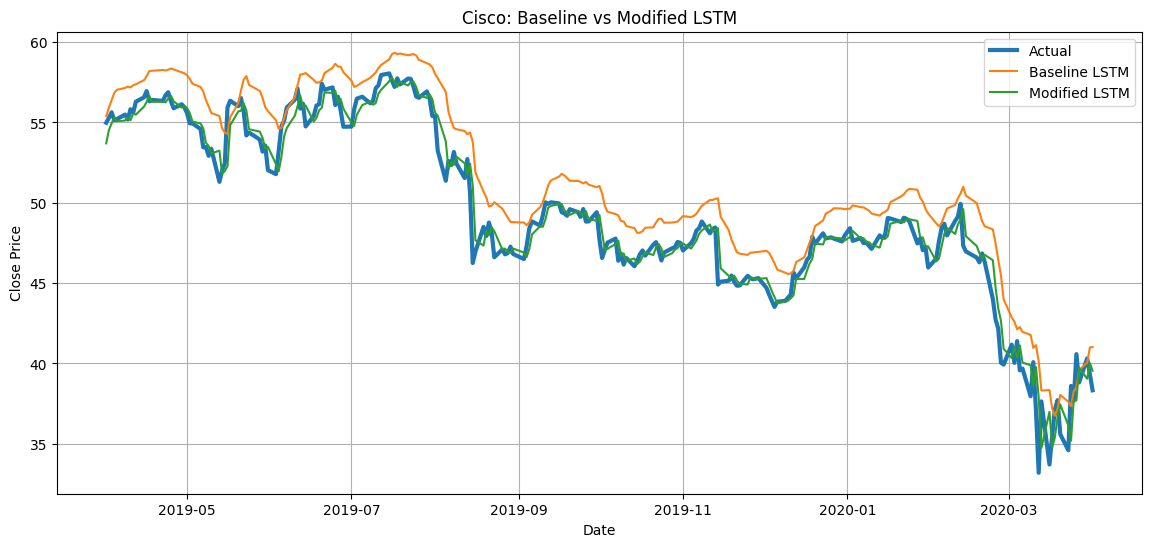

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    test2['Date'],
    test2['Close'],
    linewidth=3,
    label='Actual')

plt.plot(
    test2['Date'],
    predictions2,
    label='Baseline LSTM')

plt.plot(
    test2['Date'],
    predictionsmod2,
    label='Modified LSTM')

plt.title('Cisco: Baseline vs Modified LSTM')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.show()

# Evaluation

In [48]:
from sklearn.metrics import (mean_squared_error,mean_squared_error,mean_absolute_error,
                             mean_absolute_percentage_error)

results = pd.DataFrame({
    'Dataset': ['Amazon', 'Amazon', 'Cisco', 'Cisco'],
    'Model': ['AMZNBase', 'AMZNModified', 'CSCOBase', 'CSCOModified'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, predictions)),
        np.sqrt(mean_squared_error(y_test, predictionsmod)),
        np.sqrt(mean_squared_error(y_test2, predictions2)),
        np.sqrt(mean_squared_error(y_test2, predictionsmod2))],
    'MAE': [
        mean_absolute_error(y_test, predictions),
        mean_absolute_error(y_test, predictionsmod),
        mean_absolute_error(y_test2, predictions2),
        mean_absolute_error(y_test2, predictionsmod2)],
    'MAPE (%)': [
        mean_absolute_percentage_error(y_test, predictions) * 100,
        mean_absolute_percentage_error(y_test, predictionsmod) * 100,
        mean_absolute_percentage_error(y_test2, predictions2) * 100,
        mean_absolute_percentage_error(y_test2, predictionsmod2) * 100]})

print(results.round(4))

  Dataset         Model      RMSE       MAE  MAPE (%)
0  Amazon      AMZNBase  391.8086  388.3095   20.8572
1  Amazon  AMZNModified   44.1086   31.2270    1.6861
2   Cisco      CSCOBase    2.3042    1.9998    4.1733
3   Cisco  CSCOModified    1.0459    0.7193    1.5474


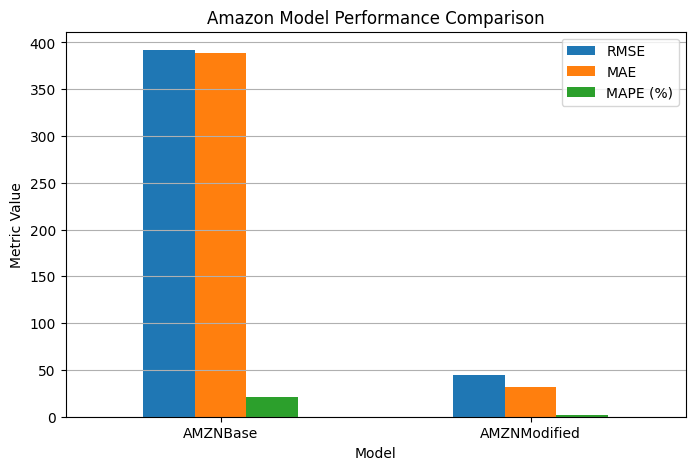

In [49]:
amazon_results = results[results['Dataset'] == 'Amazon']
amazon_results.set_index('Model')[['RMSE','MAE','MAPE (%)']].plot(kind='bar',figsize=(8,5),
    title='Amazon Model Performance Comparison')

plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

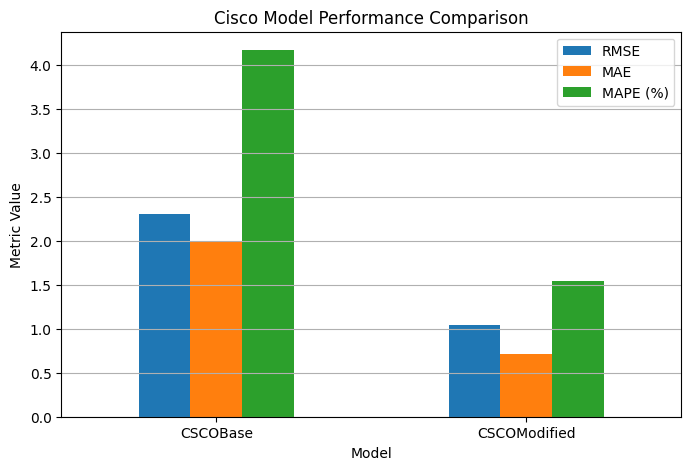

In [50]:
cisco_results = results[results['Dataset'] != 'Amazon']
cisco_results.set_index('Model')[['RMSE','MAE','MAPE (%)']].plot(
    kind='bar',
    figsize=(8,5),
    title='Cisco Model Performance Comparison'
)

plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()